In [1]:
%load_ext autoreload
%autoreload 2

In [61]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pygtc
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
# early = jsm_visualize.Arborist(file="../../../StellarHalo/data/four_examples/DF/early_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
# middle = jsm_visualize.Arborist(file="../../../StellarHalo/data/four_examples/DF/middle_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
# late = jsm_visualize.Arborist(file="../../../StellarHalo/data/four_examples/DF/late_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
# latest = jsm_visualize.Arborist(file="../../../StellarHalo/data/four_examples/DF/latest_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)

In [5]:
bigboi = jsm_visualize.Arborist(file="../../data/prelim/tree_14.0_15100_evo.npz", merger_crit=-2, verbose=False)

In [6]:
# bigboi.plant_roots()
# bigboi.water_roots()
# bigboi.dendrochronology(mass_threshold=6.75e9)
bigboi.canopy(mass_threshold=6.75e9)
bigboi.ave_canopy(mass_threshold=6.75e9)

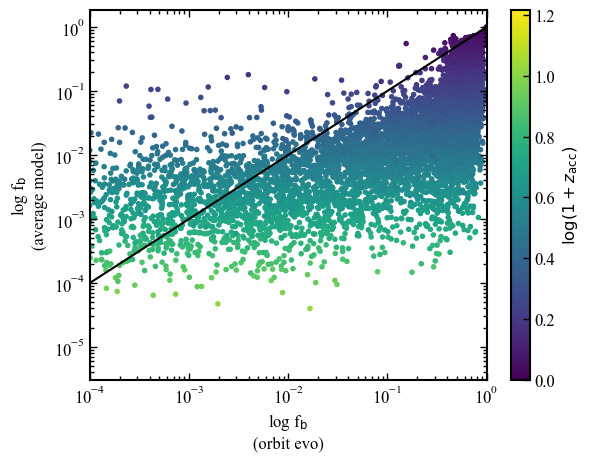

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

fig, ax = plt.subplots()

log1pz = np.log10(1 + bigboi.acc_redshift)

norm = colors.Normalize(
    vmin=log1pz.min(),
    vmax=log1pz.max()
)

sc = ax.scatter(
    bigboi.fb[:, 0],
    bigboi.ave_mass[:, 0]/bigboi.acc_mass,marker=".",
    c=log1pz,
    cmap="viridis",
    norm=norm
)

ax.plot(np.linspace(0,1), np.linspace(0,1), c="black")

ax.set_xscale("log")
ax.set_yscale("log")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\log(1+z_{\rm acc})$")

ax.set_xlim(1e-4, 1)
# ax.set_ylim(1e-4, 1)

ax.set_xlabel("log f$_{\\rm b}$ \n(orbit evo)")
ax.set_ylabel("log f$_{\\rm b}$ \n(average model)")
plt.show()

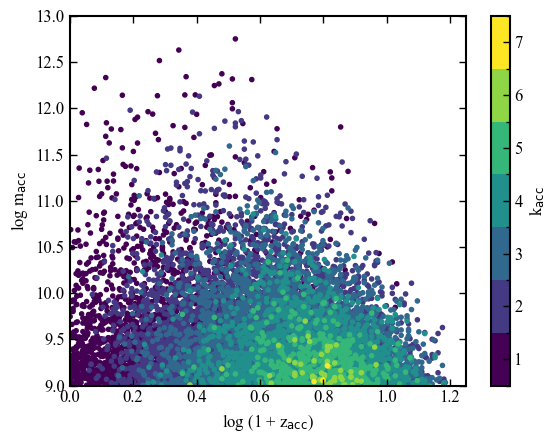

In [8]:
orders = bigboi.acc_order[1:]

fig, ax = plt.subplots()

bounds = np.arange(0.5, 7.5 + 1, 1)   # edges between integers
norm = colors.BoundaryNorm(bounds, ncolors=plt.cm.viridis.N)

sc = ax.scatter(
    np.log10(1 + bigboi.acc_redshift[1:]),
    np.log10(bigboi.acc_mass[1:]),
    c=orders,
    marker=".",
    cmap="viridis",
    norm=norm
)

cbar = fig.colorbar(sc, ax=ax, ticks=np.arange(1, 8))
cbar.set_label("k$_{\\rm acc}$")

ax.set_xlabel("log (1 + z$_{\\rm acc}$)")
ax.set_ylabel("log m$_{\\rm acc}$")
ax.set_xlim(0, 1.25)
ax.set_ylim(9, 13)

plt.show()

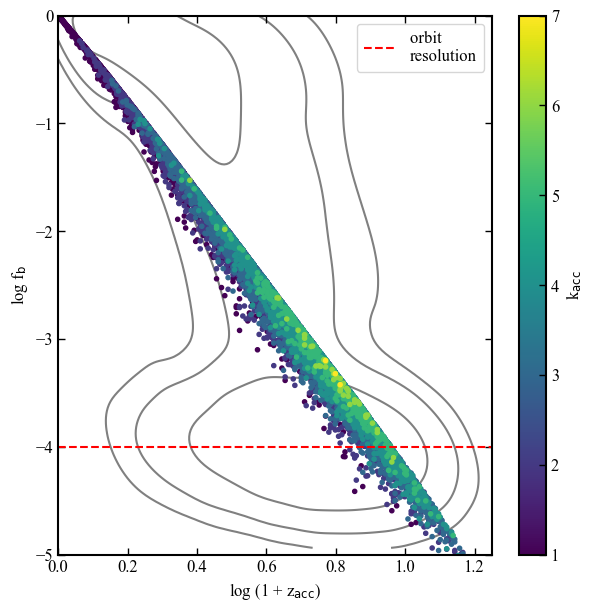

In [9]:
plt.figure(figsize=(double_textwidth, double_textwidth))

#plt.scatter(np.log10(1+bigboi.acc_redshift[1:]), np.log10(bigboi.mass[1:, 0]/bigboi.acc_mass[1:]), c= bigboi.acc_order[1:],marker=".")
sns.kdeplot(x=np.log10(1+bigboi.acc_redshift[1:]), y=np.log10(bigboi.mass[1:, 0]/bigboi.acc_mass[1:]), levels=levelz, color="grey", zorder=1)
plt.scatter(np.log10(1+bigboi.acc_redshift[1:]), np.log10(bigboi.ave_mass[1:, 0]/bigboi.acc_mass[1:]), c= bigboi.acc_order[1:],marker=".")

plt.axhline(-4, ls="--", color="red", label="orbit \nresolution")
# plt.axhline(np.log10(6.75e9), ls="--", color="k", label="particle \nresolution")

plt.legend()
plt.xlabel("log (1 + z$_{\\rm acc}$)")
plt.ylabel("log f$_{\\rm b}$")
plt.colorbar(label="k$_{\\rm acc}$")
plt.xlim(0, 1.25)
plt.ylim(-5, 0)
plt.show()

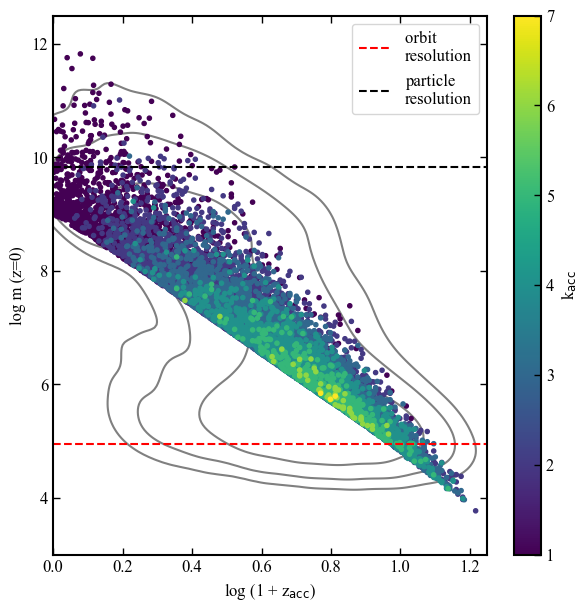

In [10]:
plt.figure(figsize=(double_textwidth, double_textwidth))

#plt.scatter(np.log10(1+bigboi.acc_redshift[1:]), np.log10(bigboi.mass[1:, 0]), c= bigboi.acc_order[1:],marker=".")
sns.kdeplot(x=np.log10(1+bigboi.acc_redshift[1:]), y=np.log10(bigboi.mass[1:, 0]), levels=levelz, color="grey", zorder=1)
plt.scatter(np.log10(1+bigboi.acc_redshift[1:]), np.log10(bigboi.ave_mass[1:, 0]), c= bigboi.acc_order[1:],marker=".")

plt.axhline(4.95, ls="--", color="red", label="orbit \nresolution")
plt.axhline(np.log10(6.75e9), ls="--", color="k", label="particle \nresolution")

plt.legend()
plt.xlabel("log (1 + z$_{\\rm acc}$)")
plt.ylabel("log m (z=0)")
plt.colorbar(label="k$_{\\rm acc}$")
plt.xlim(0, 1.25)
plt.ylim(3, 12.5)
plt.show()

In [11]:
def plot_fb_space(order, kmax=7):

    zacc = np.log10(1 + bigboi.acc_redshift[1:])
    fb_kde = np.log10(bigboi.mass[1:, 0] / bigboi.acc_mass[1:])
    fb = np.log10(bigboi.mass[1:, 0] / bigboi.acc_mass[1:])
    orders = bigboi.acc_order[1:]

    mask = orders == order

    cmap = plt.cm.get_cmap("viridis", kmax)
    color = cmap(order - 1)

    fig, ax = plt.subplots(figsize=(double_textwidth, double_textwidth))

    sns.kdeplot(
        x=zacc,
        y=fb_kde,
        levels=levelz,
        color="grey",
        zorder=1,
        ax=ax
    )

    ax.scatter(
        zacc[mask],
        fb[mask],
        marker=".",
        color=color,
        label=f"k={order}"
    )

    ax.axhline(-4, ls="--", color="red", label="orbit \nresolution")

    ax.set_xlabel("log (1 + z$_{\\rm acc}$)")
    ax.set_ylabel("log f$_{\\rm b}$")
    ax.set_xlim(0, 1.25)
    ax.set_ylim(-4.1, 0)

    ax.legend()

    plt.show()

In [12]:
# plot_fb_space(1)
# plot_fb_space(2)
# plot_fb_space(3)
# plot_fb_space(4)

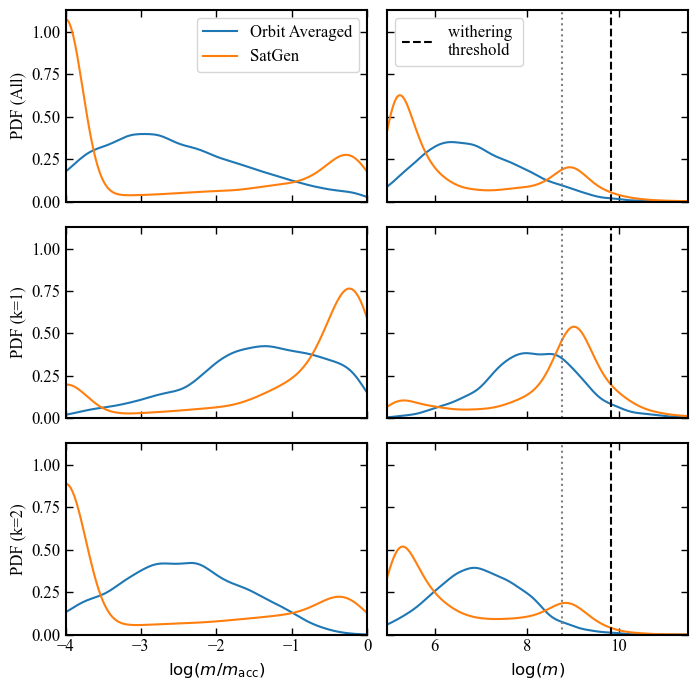

In [13]:
fig, ax = plt.subplots(
    3, 2,
    sharex="col",
    sharey=True,
    figsize=(double_textwidth, double_textwidth)
)

orders = [None, 1, 2]

for i, order in enumerate(orders):

    if order is None:
        mask = np.ones_like(bigboi.acc_order[1:], dtype=bool)
        row_label = "PDF (All)"
    else:
        mask = (bigboi.acc_order[1:] == order)
        row_label = f"PDF (k={order})"

    ave_mass = bigboi.ave_mass[1:,0][mask]
    mass = bigboi.mass[1:,0][mask]
    acc_mass = bigboi.acc_mass[1:][mask]

    # --- mass fraction ---
    sns.kdeplot(np.log10(ave_mass/acc_mass), ax=ax[i,0], label="Orbit Averaged")
    sns.kdeplot(np.log10(mass/acc_mass), ax=ax[i,0], label="SatGen")

    # --- absolute mass ---
    sns.kdeplot(np.log10(ave_mass), ax=ax[i,1])
    sns.kdeplot(np.log10(mass), ax=ax[i,1])

    ax[i,0].set_ylabel(row_label)

# axis limits
ax[0,0].set_xlim(-4,0)
ax[0,1].set_xlim(np.log10(bigboi.acc_mass[1:].min())-4, 11.5)

# resolution line
mcut = np.log10(6.75e9)
for i in range(3):
    ax[i,1].axvline(mcut, ls="--", color="k", label="withering \nthreshold")
    ax[i,1].axvline(np.log10(bigboi.acc_mass[1:].max())-4, ls=":",color="grey")

ax[0, 1].legend()

# x labels only on bottom
ax[2,0].set_xlabel(r"$\log(m/m_{\rm acc})$")
ax[2,1].set_xlabel(r"$\log(m)$")

# legend once
ax[0,0].legend()

plt.tight_layout()
plt.show()

In [14]:
bigboi = jsm_visualize.Tree_Vis(file="../../data/prelim/tree_14.0_15100_evo.npz", merger_crit=-2, verbose=False)

In [15]:
rmax_acc = bigboi.rmax_kscaled[np.arange(bigboi.acc_index.shape[0]), bigboi.acc_index]

vmax_acc = bigboi.Vmax_kscaled[np.arange(bigboi.acc_index.shape[0]), bigboi.acc_index]

k1 = bigboi.acc_order == 1

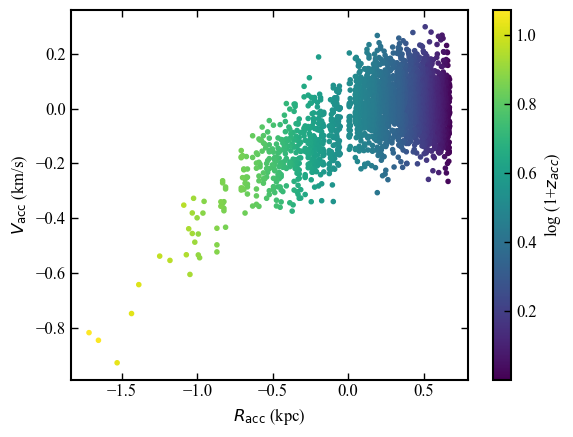

In [16]:
plt.scatter(rmax_acc[k1], vmax_acc[k1], marker=".",  c=np.log10(1 + bigboi.acc_redshift[k1]))
plt.colorbar(label="log (1+$z_{acc}$)")
plt.xlabel("$R_{\\rm acc}$ (kpc)")
plt.ylabel("$V_{\\rm acc}$ (km/s)")

plt.show()

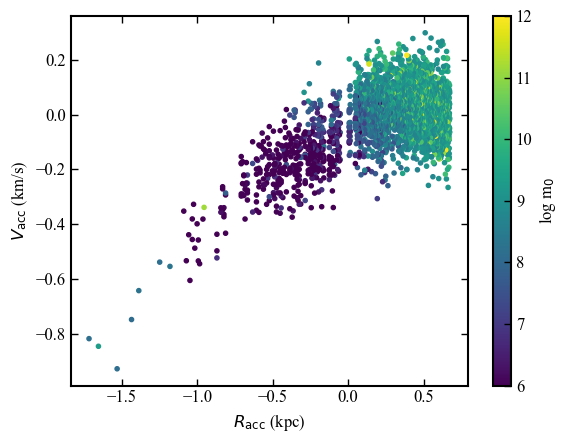

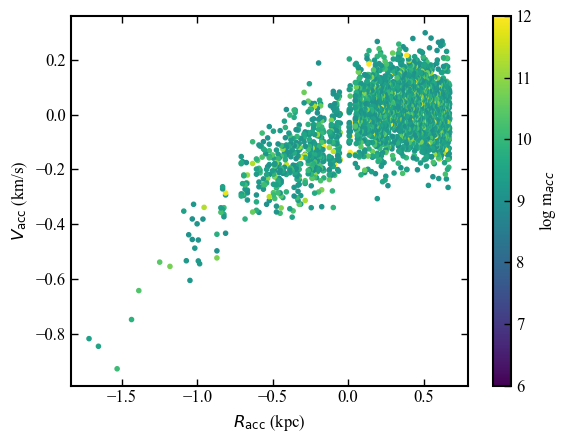

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import numpy as np

m0 = np.log10(bigboi.final_mass[k1])
macc = np.log10(bigboi.acc_mass[k1])


norm = colors.Normalize(vmin=6, vmax=12)

cmap = cm.viridis

# shared colorbar object
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# --- first plot ---
fig, ax = plt.subplots()

ax.scatter(rmax_acc[k1], vmax_acc[k1], marker=".", c=m0, cmap=cmap, norm=norm)

fig.colorbar(sm, ax=ax, label="log m$_{0}$")
ax.set_xlabel("$R_{\\rm acc}$ (kpc)")
ax.set_ylabel("$V_{\\rm acc}$ (km/s)")
# ax.set_xlim(0, 1250)
# ax.set_ylim(0, 1500)

plt.show()


# --- second plot ---
fig, ax = plt.subplots()

ax.scatter(rmax_acc[k1], vmax_acc[k1], marker=".", c=macc, cmap=cmap, norm=norm)

fig.colorbar(sm, ax=ax, label="log m$_{acc}$")
ax.set_xlabel("$R_{\\rm acc}$ (kpc)")
ax.set_ylabel("$V_{\\rm acc}$ (km/s)")
# ax.set_xlim(0, 1250)
# ax.set_ylim(0, 1500)

plt.show()

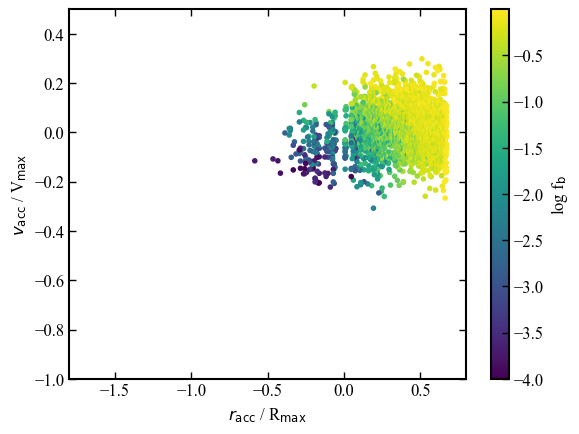

In [18]:
plt.scatter(rmax_acc[k1], vmax_acc[k1], marker=".", c=np.log10(bigboi.fb[:, 0][k1]))
plt.colorbar(label="log f$_{\\rm b}$")
plt.xlabel("$r_{\\rm acc}$ / R$_{\\rm max}$")
plt.ylabel("$v_{\\rm acc}$ / V$_{\\rm max}$")

plt.xlim(-1.8, 0.8)
plt.ylim(-1.0, 0.5)


plt.show()

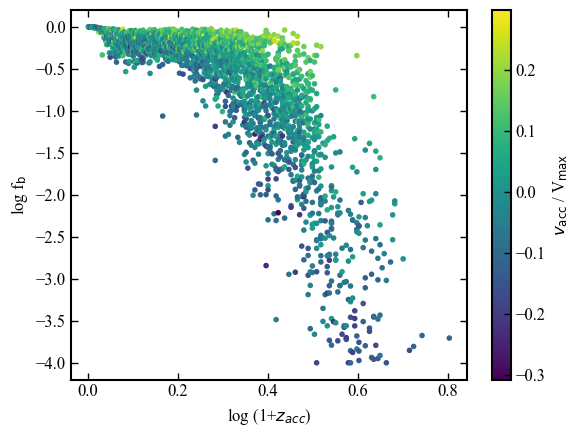

In [19]:
plt.scatter(np.log10(1 + bigboi.acc_redshift[k1]), np.log10(bigboi.fb[:, 0][k1]), marker=".", c=vmax_acc[k1])
plt.colorbar(label="$v_{\\rm acc}$ / V$_{\\rm max}$")
plt.xlabel("log (1+$z_{acc}$)")
plt.ylabel("log f$_{\\rm b}$")


plt.show()

In [50]:
# bigboi.make_orbit_movie(video_path="../../data/movies/bigboi.mp4", scale=1200)
k2 = bigboi.acc_order == 2

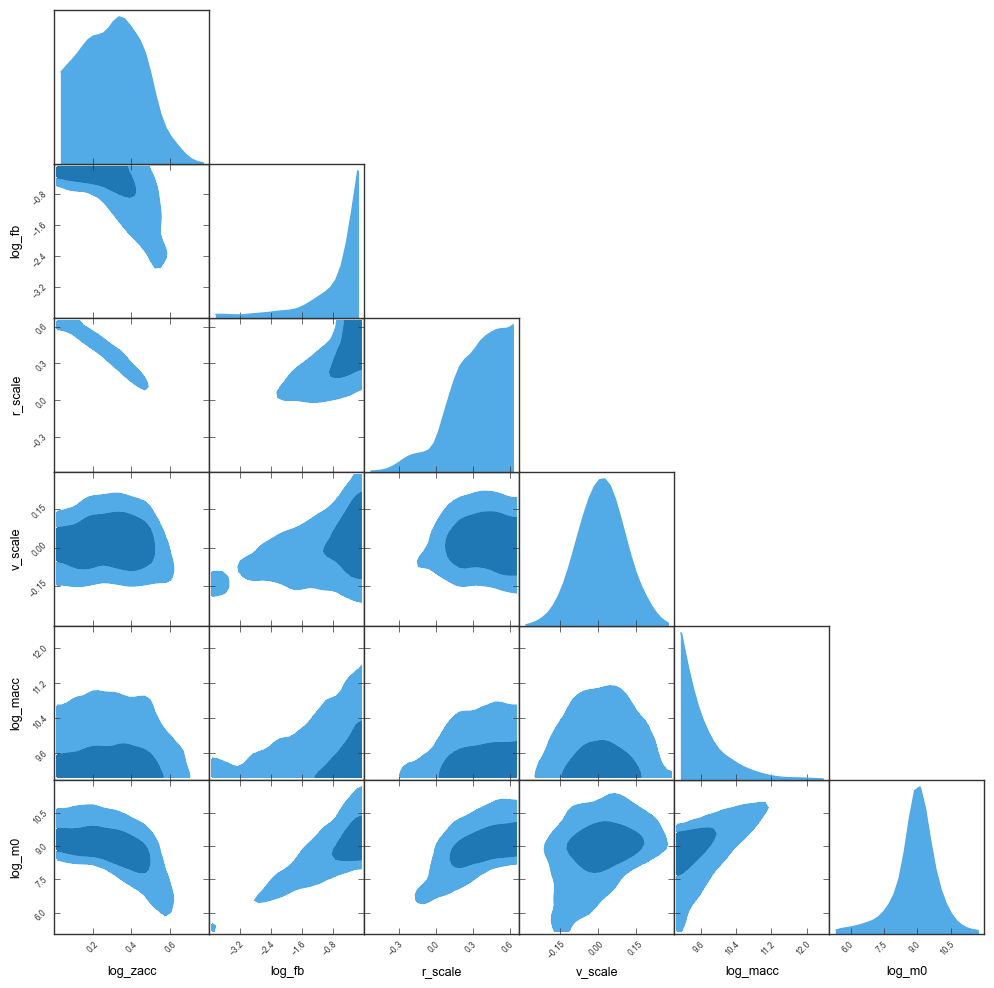

In [62]:
test = pd.DataFrame({"log_zacc": np.log10(1 + bigboi.acc_redshift[k1]), "log_fb": np.log10(bigboi.fb[:, 0][k1]),
                     "r_scale": rmax_acc[k1], "v_scale": vmax_acc[k1], "log_macc": np.log10(bigboi.acc_mass[k1]), "log_m0": np.log10(bigboi.final_mass[k1]) })

test.replace([np.inf, -np.inf], np.nan, inplace=True)
test = test.dropna()

corner_comp = pygtc.plotGTC(chains=test, figureSize=12, smoothingKernel=1.5)

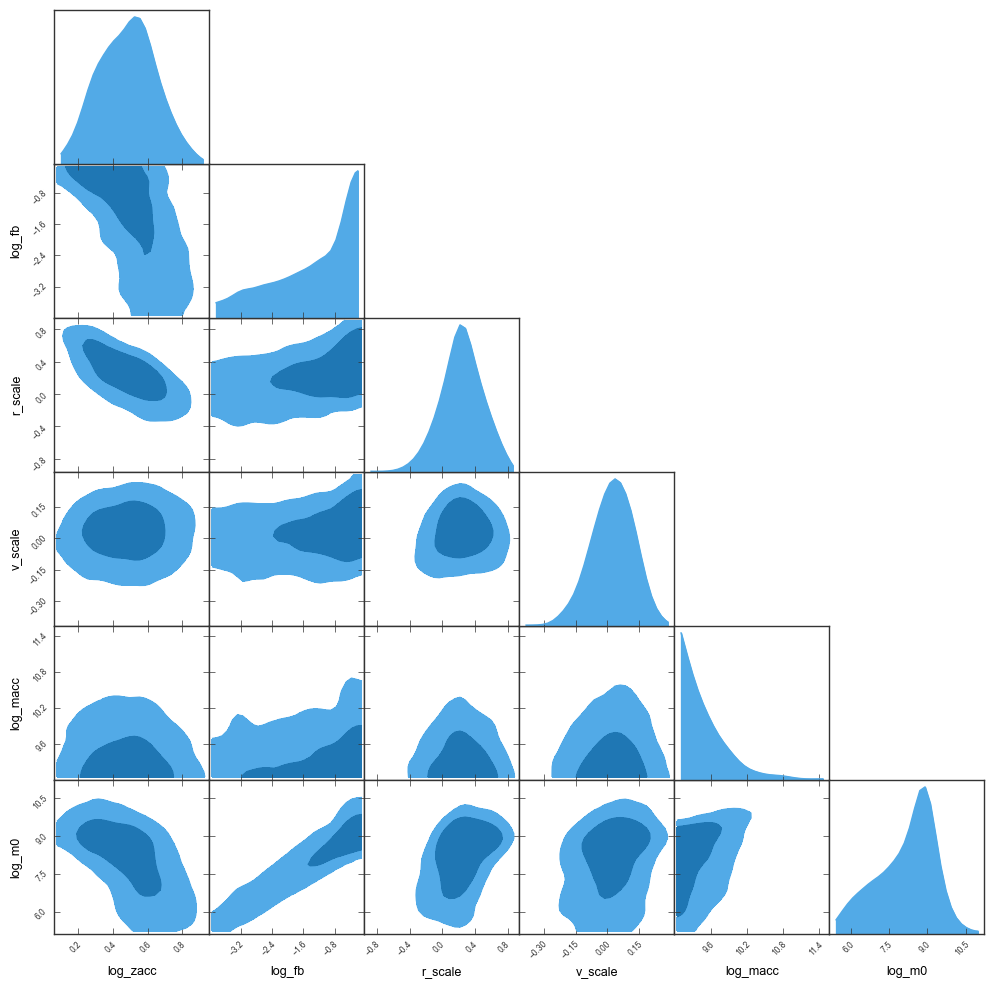

In [63]:
k2 = bigboi.acc_order == 2

test = pd.DataFrame({"log_zacc": np.log10(1 + bigboi.acc_redshift[k2]), "log_fb": np.log10(bigboi.fb[:, 0][k2]),
                     "r_scale": rmax_acc[k2], "v_scale": vmax_acc[k2], "log_macc": np.log10(bigboi.acc_mass[k2]), "log_m0": np.log10(bigboi.final_mass[k2]) })

test.replace([np.inf, -np.inf], np.nan, inplace=True)
test = test.dropna()

corner_comp = pygtc.plotGTC(chains=test, figureSize=12, smoothingKernel=1.5)

In [65]:
rmags = bigboi.rmags[np.arange(bigboi.acc_index.shape[0]), bigboi.acc_index]

vmags = bigboi.Vmags[np.arange(bigboi.acc_index.shape[0]), bigboi.acc_index]

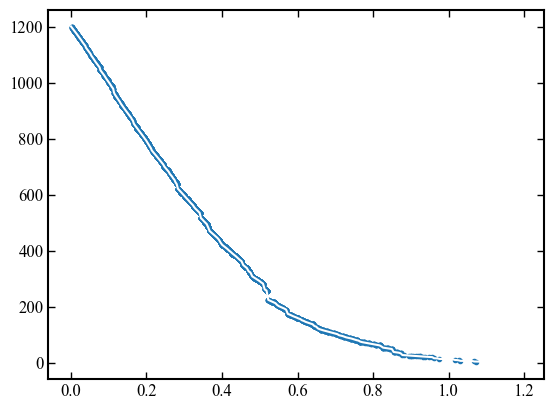

In [77]:
# plt.scatter(np.log10(1 + bigboi.acc_redshift[k1]), rmags[k1])
plt.plot(np.log10(1 + cfg.zsample), bigboi.VirialRadius[0], color="white")
plt.scatter(np.log10(1 + bigboi.acc_redshift[k1]), rmags[k1], marker=".")


In [73]:
bigboi.VirialRadius[0]

array([1201.8188   , 1198.6061   , 1195.1958   , 1191.9734   ,
       1188.6611   , 1185.2605   , 1181.9288   , 1178.6024   ,
       1175.1191   , 1171.8246   , 1168.5067   , 1164.8469   ,
       1161.454    , 1158.0858   , 1154.466    , 1150.3468   ,
       1146.0863   , 1142.59     , 1139.0328   , 1135.5905   ,
       1132.0992   , 1125.1625   , 1121.4655   , 1117.9463   ,
       1114.3954   , 1110.8744   , 1107.3945   , 1103.6615   ,
       1097.4543   , 1093.8682   , 1090.0225   , 1085.7782   ,
       1081.912    , 1077.4043   , 1073.6367   , 1069.9314   ,
       1066.2949   , 1062.5353   , 1058.8888   , 1055.0845   ,
       1045.147    , 1041.458    , 1037.6423   , 1033.463    ,
       1029.7732   , 1026.0839   , 1021.4448   , 1017.08905  ,
       1012.74524  , 1008.88727  , 1005.0254   , 1000.60175  ,
        996.53986  ,  991.5568   ,  987.1679   ,  982.95685  ,
        979.1449   ,  965.4577   ,  958.9051   ,  954.45996  ,
        950.0778   ,  946.22125  ,  940.823    ,  936.7